In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv("../data/raw/housing.csv")

print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully
Rows: 20640
Columns: 9


In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [11]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [12]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [13]:
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 20640
Number of columns: 9


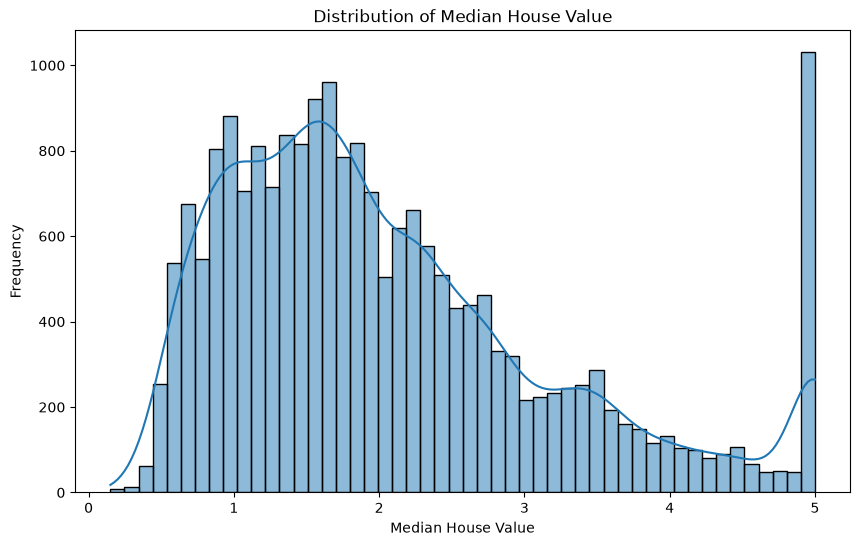

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["MedHouseVal"],
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

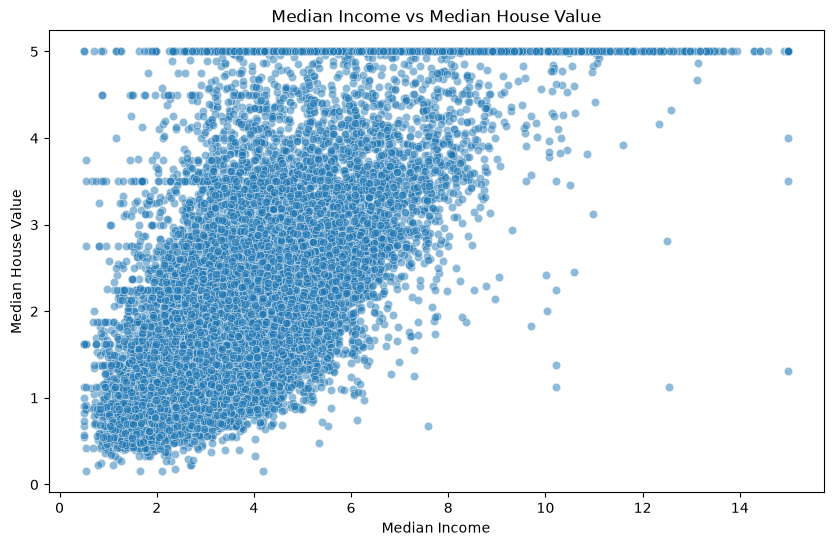

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.5
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

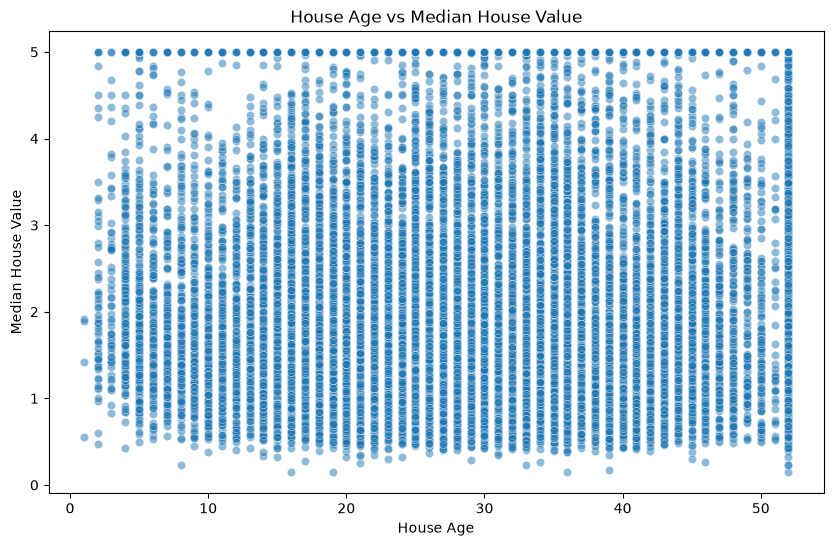

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HouseAge",
    y="MedHouseVal",
    alpha=0.5
)

plt.title("House Age vs Median House Value")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.show()

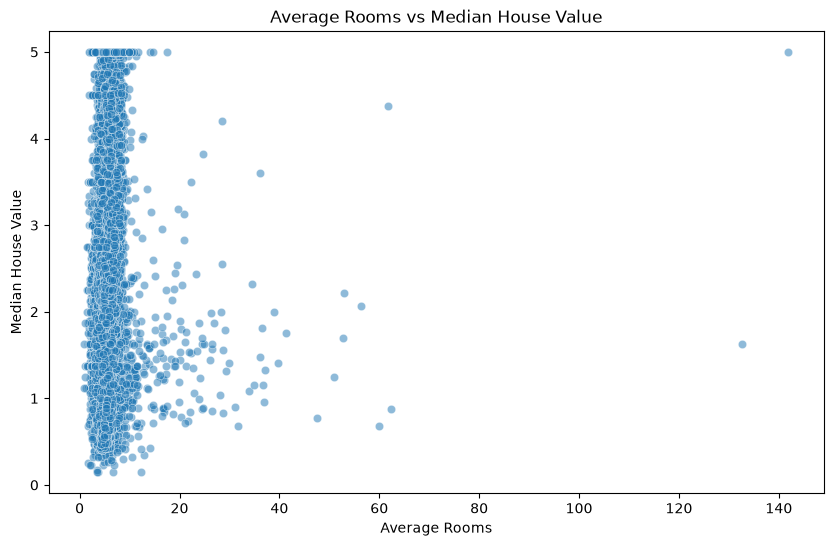

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="AveRooms",
    y="MedHouseVal",
    alpha=0.5
)

plt.title("Average Rooms vs Median House Value")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.show()

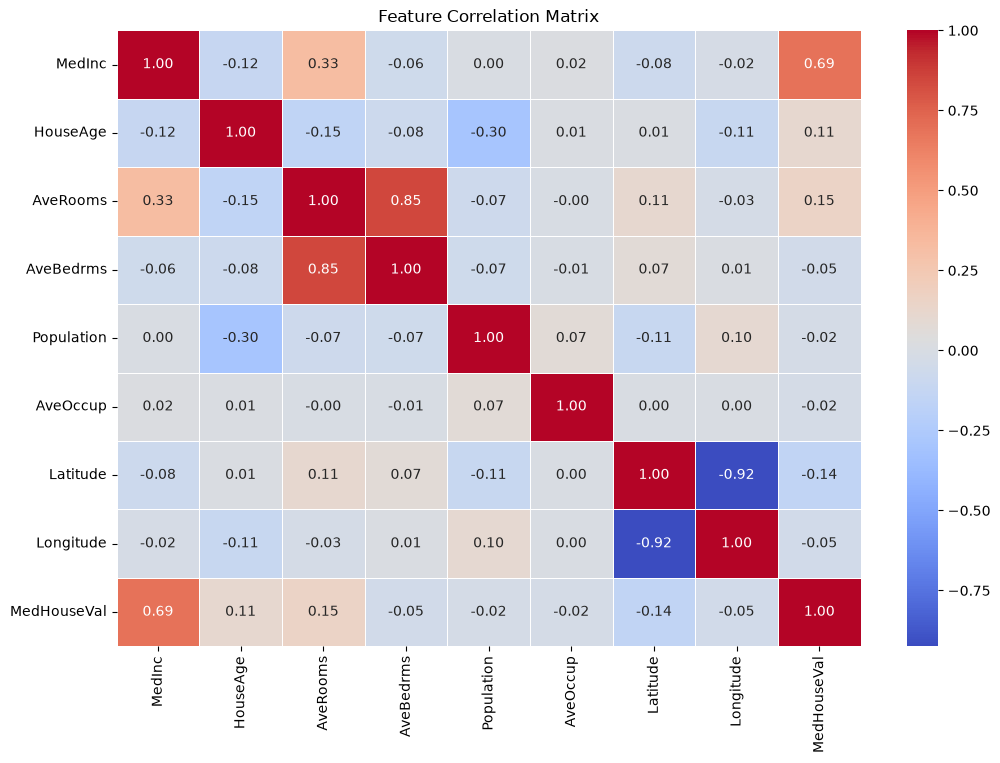

In [21]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

In [22]:
target_correlation = (
    df.corr()["MedHouseVal"]
    .sort_values(ascending=False)
)

print("Correlation with Median House Value:")
print(target_correlation)

Correlation with Median House Value:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [23]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("MedHouseVal")

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
MedHouseVal


In [24]:
print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature shape: (20640, 8)
Target shape: (20640,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


In [26]:
model = LinearRegression()

print("Linear Regression model created successfully")

Linear Regression model created successfully


In [27]:
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [28]:
y_pred = model.predict(X_test)

print("Predictions generated successfully")
print(f"Number of predictions: {len(y_pred)}")

Predictions generated successfully
Number of predictions: 4128


In [29]:
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")

Mean Absolute Error: 0.5332


In [30]:
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.5559


In [31]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.5758


In [32]:
metrics = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Mean Squared Error",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        r2
    ]
})

metrics

,Metric,Value
0,Mean Absolute Error,0.533200
1,Mean Squared Error,0.555892
2,R² Score,0.575788


In [33]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


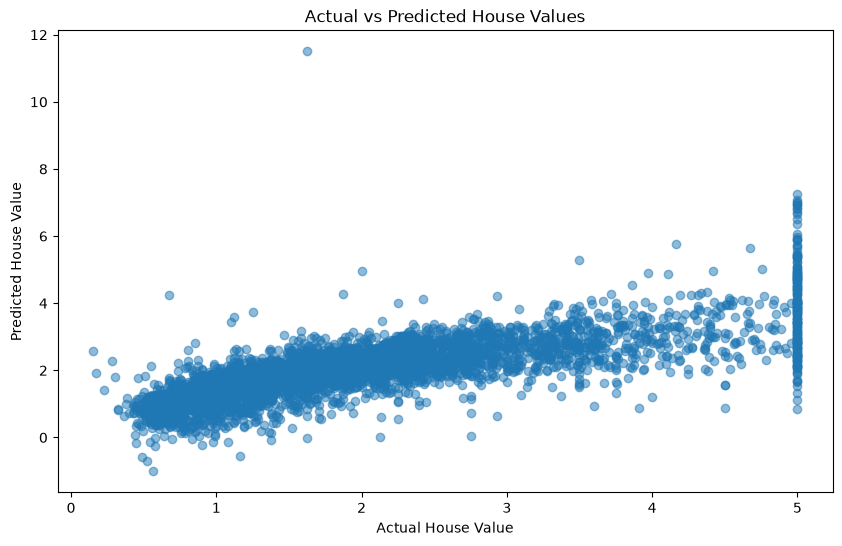

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

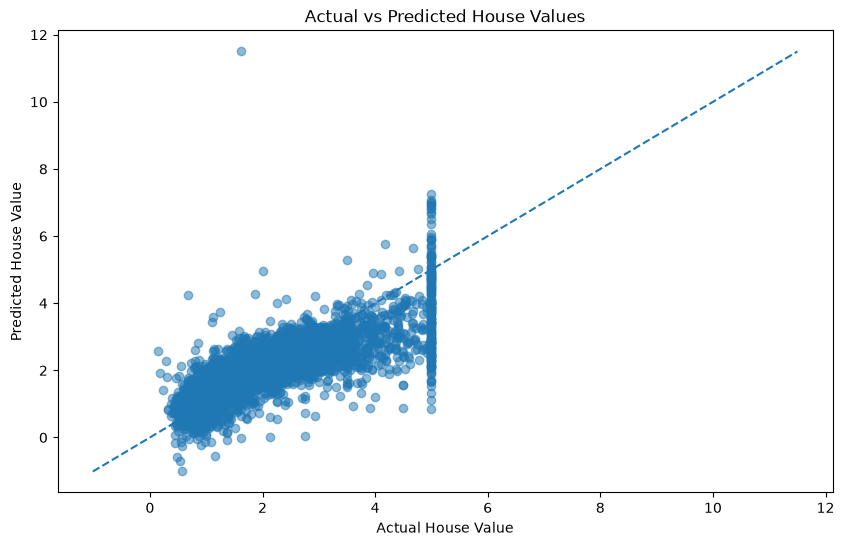

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [36]:
residuals = y_test - y_pred

print(residuals.describe())

count    4128.000000
mean        0.003479
std         0.745664
min        -9.875331
25%        -0.460935
50%        -0.122439
75%         0.312442
max         4.148388
Name: MedHouseVal, dtype: float64


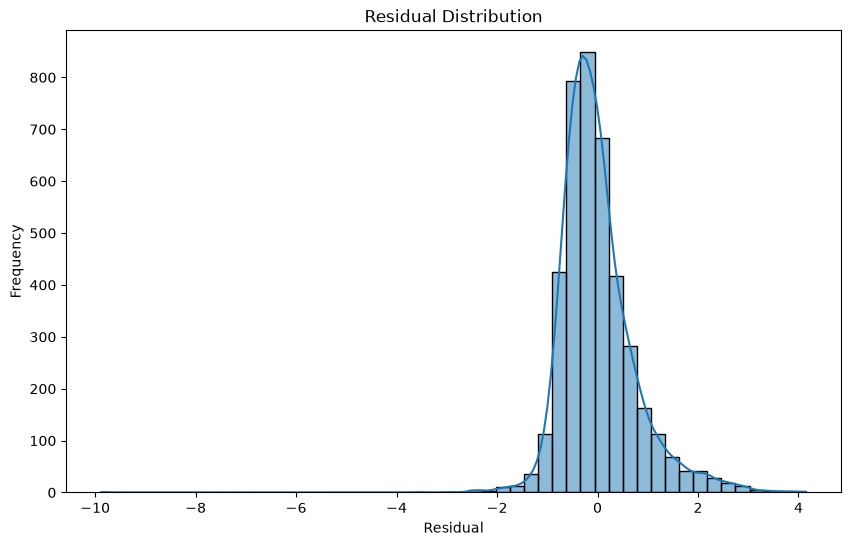

In [37]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

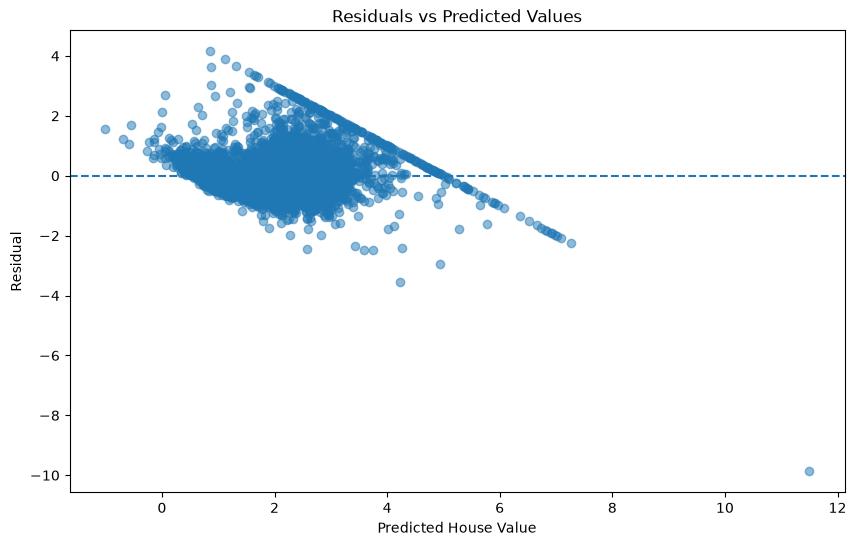

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

In [39]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
3,AveBedrms,0.783145,0.783145
0,MedInc,0.448675,0.448675
7,Longitude,-0.433708,0.433708
6,Latitude,-0.419792,0.419792
2,AveRooms,-0.123323,0.123323
1,HouseAge,0.009724,0.009724
5,AveOccup,-0.003526,0.003526
4,Population,-0.000002,0.000002


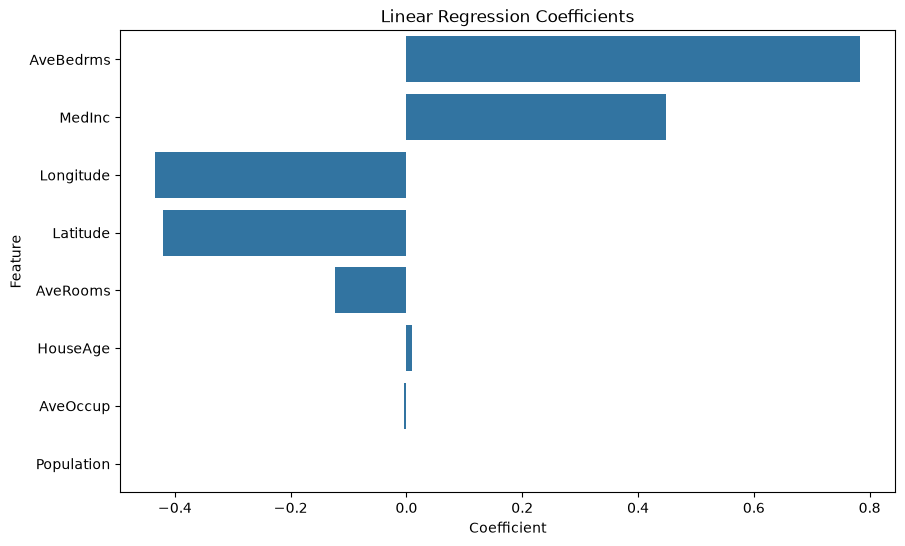

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [41]:
new_house = pd.DataFrame({
    "MedInc": [5.0],
    "HouseAge": [20.0],
    "AveRooms": [6.0],
    "AveBedrms": [1.0],
    "Population": [1500.0],
    "AveOccup": [3.0],
    "Latitude": [34.05],
    "Longitude": [-118.25]
})

new_house

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,5.0,20.0,6.0,1.0,1500.0,3.0,34.05,-118.25


In [42]:
predicted_value = model.predict(new_house)[0]

print(
    f"Predicted Median House Value: ${predicted_value * 100000:,.2f}"
)

Predicted Median House Value: $243,620.80


In [43]:
print("=" * 50)
print("HOUSE PRICE PREDICTION MODEL")
print("=" * 50)

print(f"Dataset Size      : {len(df):,} rows")
print(f"Training Samples  : {len(X_train):,}")
print(f"Testing Samples   : {len(X_test):,}")

print("\nModel:")
print("Linear Regression")

print("\nEvaluation Metrics:")
print(f"MAE               : {mae:.4f}")
print(f"MSE               : {mse:.4f}")
print(f"R² Score          : {r2:.4f}")

print("\nExample Prediction:")
print(f"Predicted Value   : ${predicted_value * 100000:,.2f}")

print("=" * 50)

HOUSE PRICE PREDICTION MODEL
Dataset Size      : 20,640 rows
Training Samples  : 16,512
Testing Samples   : 4,128

Model:
Linear Regression

Evaluation Metrics:
MAE               : 0.5332
MSE               : 0.5559
R² Score          : 0.5758

Example Prediction:
Predicted Value   : $243,620.80
